In [2]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

from hubble_fit import *

In [3]:

# Load Pantheon+ SN metadata
print("Loading Pantheon+ supernova data...")
df_pantheon = pd.read_csv(
    #"https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat",
    "data/Pantheon+SH0ES.dat",
    sep=r"\s+"
)

print("Loading SN covariance matrix...")
n_sn = len(df_pantheon)

# Load .cov file with NumPy, skipping the first line (which contains just "1701")
cov_flat = np.loadtxt(
    #"https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES_STAT%2BSYS.cov",
    "data/Pantheon+SH0ES_STAT+SYS.cov",
    skiprows=1
)

# Reshape into square matrix
cov_matrix = cov_flat.reshape((n_sn, n_sn))

# Confirm shape is correct
assert cov_matrix.shape == (n_sn, n_sn), f"Expected ({n_sn},{n_sn}), got {cov_matrix.shape}"

# Invert covariance and pre-compute log-determinant for SN likelihood
global Cov_inv, logdetCov
Cov_inv = np.linalg.inv(cov_matrix)
sign, logdet = np.linalg.slogdet(cov_matrix)
if sign <= 0:
    raise ValueError("Covariance matrix is not positive-definite!")
logdetCov = logdet
print("Data loaded. Running joint cosmographic fits...")


Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Data loaded. Running joint cosmographic fits...


In [3]:
df_agn = load_quasar_data("data/july27_chisq2_preview_tree8_N20w4000s500_merged.h5", populate_sdss=False)

print(list(df_agn.keys()))


Reading quasars from HDF5: 100%|██████████| 58/58 [00:00<00:00, 347.58it/s]


Number of quasars loaded: 58
   object_id    chi_sq       ebv         z  EXTINCTION        M_i
0    1384141  6.294867  0.302981  0.329846    1.075510 -22.982048
1    1384142  8.473950  0.301818  2.445898    1.071410 -28.372445
2    1384143  8.662985  0.273010  1.838447    0.969115 -26.271487
3    1384144  4.035444  0.248959  1.885438    0.883784 -26.304172
4    1384145  4.061303  0.167054  2.740166    0.592995 -26.666071
Columns with NaNs: ['log_sigma_band_g', 'log_sigma_band_g_err', 'log_sigma_band_u', 'log_sigma_band_u_err']
Before dropping NaNs and infs, number of quasars: 58
Number of quasars with 0 < z <= 0.5: 2
Number of quasars with z > 3: 1
Before data cuts, number of quasars: 58
Number of quasars with 0 < z <= 0.5: 2
Number of quasars with z > 3: 1
Number of quasars with 0 < z <= 0.5: 0
Number of dropped quasars with 0 < z <= 0.5: 2
Number of quasars with z > 3: 0
Final number of quasars: 51
['object_id', 'EXTINCTION', 'FHOST_5100', 'LOGL1350', 'LOGL1350_ERR', 'LOGL1700', 'LOG

In [6]:
#df_agn = load_quasar_data("data/july12_joint_mean1_zsort_N20w2000s500_merged.h5", populate_sdss=False)
df_agn = load_quasar_data("data/july31_chisq2_preview_tree8_N10w1000s250_merged.h5", populate_sdss=False)


Reading quasars from HDF5: 100%|██████████| 442/442 [00:01<00:00, 388.46it/s]


Number of quasars loaded: 442
   object_id    chi_sq       ebv         z  EXTINCTION        M_i
0    1384141  6.294867  0.302981  0.329846    1.075510 -22.982048
1    1384142  8.473950  0.301818  2.445898    1.071410 -28.372445
2    1384143  8.662985  0.273010  1.838447    0.969115 -26.271487
3    1384144  4.035444  0.248959  1.885438    0.883784 -26.304172
4    1384145  4.061303  0.167054  2.740166    0.592995 -26.666071
Columns with NaNs: ['apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err', 'color', 'log_sigma_band_g', 'log_sigma_band_g_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'chi_sq']
Before dropping NaNs and infs, number of quasars: 442
Number of quasars with 0 < z <= 0.5: 23
Number of quasars with z > 3: 14
Before data cuts, number of quasars: 442
Number of quasars with 0 < z <= 0.5: 23
Number of quasars with z > 3: 14
Number

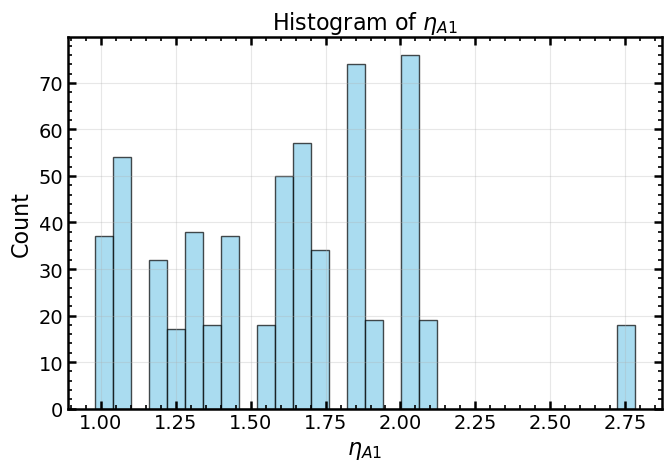

In [7]:
plt.figure(figsize=(7, 5))
plt.hist(df_agn['eta_A2'], bins=30, color='skyblue', edgecolor='k', alpha=0.7)
plt.xlabel(r'$\eta_{A1}$')
plt.ylabel('Count')
plt.title(r'Histogram of $\eta_{A1}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

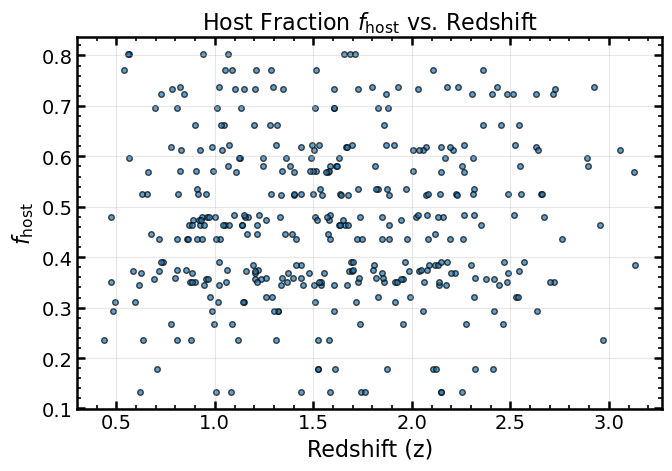

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(df_agn['z'], df_agn['f_host'], alpha=0.7, edgecolor='k')
plt.xlabel('Redshift (z)')
plt.ylabel(r'$f_{\mathrm{host}}$')
plt.title(r'Host Fraction $f_{\mathrm{host}}$ vs. Redshift')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
import hubble_fit
cosmo_model = 'FlatwCDM'
sampler, flat_samples, labels, mag_corr, logZ, logZerr = hubble_fit.run_mcmc_pipeline(df_agn, df_pantheon, fitting_method='dynesty', cosmo_model=cosmo_model,
                                                                                      completeness=True, use_full_cov=True,resume=True)


log tau UV RF pivot:  3.1209849035120443
log sigma hat sq pivot:  -1.3877201201215628
alpha_nu pivot:  -0.5
z mean: 1.619,  z_agn_pivot: 1.552


ValueError: The factored matrix c is not square.

In [4]:
residuals, mu_pred_median, mu_pred_std = plot_hubble(flat_samples, df_agn, df_pantheon, cosmo_model=cosmo_model, show=True, show_true=False)

NameError: name 'flat_samples' is not defined

In [226]:
df_agn[mu_pred_median > 48]

,object_id,CIV,EXTINCTION,FEII_OPT_EW,FEII_UV_EW,FHOST_5100,HALPHA,HBETA,LOGL1350,LOGL1350_ERR,...,z,bestP,chi_sq,alpha_nu,alpha_nu_err,MY_LOGL2500,MY_LOGL2500_ERR,f_host_4200,apparent_mag_2500,apparent_mag_2500_err
388,1445753,1547.835478,0.053617,0.0,231.480208,0.0,0.0,0.0,45.992066,0.012781,...,3.530868,"{'eta_A1': 1.2701511227629592, 'eta_A2': 1.745...",11.604626,-0.748585,0.186655,45.924785,0.009324,-1.0,24.459931,0.1
391,1446114,1549.312969,0.049944,0.0,46.302822,0.0,0.0,0.0,44.821041,0.017115,...,1.823546,"{'eta_A1': 1.5544559903198716, 'eta_A2': 0.277...",8.237360,-1.502404,0.085401,44.919441,0.005122,-1.0,25.325352,0.1


Reduced chi^2: 4.521


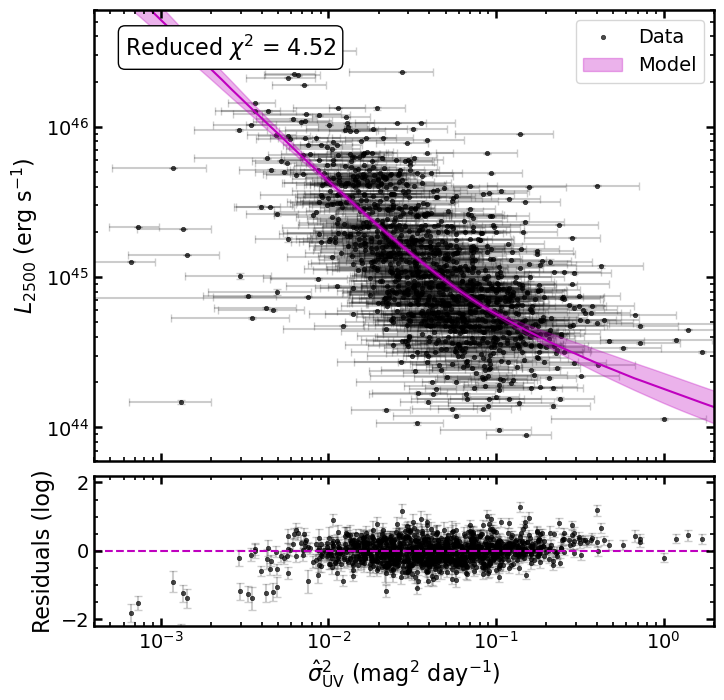

In [92]:
from scipy.interpolate import interp1d

def plot_predicted_L2500_vs_sigmahat(flat_samples, df_agn, cosmo_model, show=False):
    d = df_agn.copy()
    d = d[d['LOGL2500_ERR'] > 0]

    priors, model_labels, model_labels_latex = get_model_params(cosmo_model)
    param_indices = {name: model_labels.index(name) for name in model_labels}

    predicted_logL2500_samples = []
    predicted_logL2500_err_samples = []

    log_sigma_hat_grid = np.linspace(d['log_sigma_hat_UV'].min()-0.5, d['log_sigma_hat_UV'].max()+0.5, 100)
    for log_sigma_hat in log_sigma_hat_grid:
        for s in flat_samples:
            sample_params = {
                'M0_agn': s[param_indices['M0_agn']],
                'log_sigma_hat_sq_break': s[param_indices['log_sigma_hat_sq_break']],
                'eta_A1': s[param_indices['eta_A1_agn']],
                'eta_A2': s[param_indices['eta_A2_agn']],
                'eta_break': s[param_indices['eta_break_agn']],
                'beta': s[param_indices['beta_agn']],
            }

            predicted_M2500 = M_model_agn(
                sample_params['M0_agn'],
                sample_params['log_sigma_hat_sq_break'],
                sample_params['eta_A1'], sample_params['eta_A2'],
                sample_params['eta_break'], sample_params['beta'],
                log_sigma_hat, d['log_tau_UV_RF'].mean()
            )
            predicted_logL2500 = -0.4 * (predicted_M2500 - 90) #* np.log10(np.e)  # log10(L)
            predicted_logL2500_samples.append(predicted_logL2500)

            predicted_M2500_err = M_model_agn_err(
                sample_params['M0_agn'],
                sample_params['log_sigma_hat_sq_break'],
                sample_params['eta_A1'], sample_params['eta_A2'],
                sample_params['eta_break'], sample_params['beta'],
                log_sigma_hat, d['log_tau_UV_RF_err'].mean(), d['log_sigma_hat_UV_err'].mean()
            )
            predicted_logL2500_err = -0.4 * predicted_M2500_err #* np.log10(np.e)  # log10(L)
            predicted_logL2500_err_samples.append(predicted_logL2500_err)

    predicted_logL2500_samples = np.array(predicted_logL2500_samples)
    predicted_logL2500_samples = predicted_logL2500_samples.reshape(len(log_sigma_hat_grid), -1)

    predicted_logL2500_median = np.median(predicted_logL2500_samples, axis=1)
    predicted_logL2500_low = np.percentile(predicted_logL2500_samples, 16, axis=1)
    predicted_logL2500_high = np.percentile(predicted_logL2500_samples, 84, axis=1)

    results = {key: np.percentile(flat_samples[:, i], [16, 50, 84]) for i, key in enumerate(model_labels)}
    if cosmo_model == 'FlatwCDM':
        cosmo = FlatwCDM(H0=results['H0'][1], Om0=results['Om0'][1], w0=results['w0'][1])
    elif cosmo_model == 'Flatw0waCDM':
        cosmo = Flatw0waCDM(H0=results['H0'][1], Om0=results['Om0'][1], w0=results['w0'][1], wa=results['wa'][1])
    else:
        raise ValueError(f"Unknown cosmological model: {cosmo_model}")

    actual_M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value
    actual_logL2500 = -0.4 * (actual_M2500 - 90) #* np.log10(np.e)  # log10(L)

    log_sigma_hat_sq = 2 * d['log_sigma_hat_UV']

    # Interpolate model at data points for residuals (in log space)
    interp_model = interp1d(2*log_sigma_hat_grid, predicted_logL2500_median, bounds_error=False, fill_value='extrapolate')
    model_logL2500_at_data = interp_model(2*d['log_sigma_hat_UV'])
    residuals = actual_logL2500 - model_logL2500_at_data

    if False and 'LOGL2500_ERR' in d.columns:
        obs_err = d['LOGL2500_ERR']
    else:
        interp_low = interp1d(2*log_sigma_hat_grid, predicted_logL2500_low, bounds_error=False, fill_value='extrapolate')
        interp_high = interp1d(2*log_sigma_hat_grid, predicted_logL2500_high, bounds_error=False, fill_value='extrapolate')
        obs_err = 0.5 * (interp_high(2*d['log_sigma_hat_UV']) - interp_low(2*d['log_sigma_hat_UV']))
    
    sigma_hat_sq = 10**(2*d['log_sigma_hat_UV'])
    sigma_hat_sq_err = np.log(10) * sigma_hat_sq * 2 * d['log_sigma_hat_UV_err']
    dlogL_dlog_sigma_hat_sq = np.gradient(model_logL2500_at_data, 2*d['log_sigma_hat_UV'])
    propagated_err = np.abs(dlogL_dlog_sigma_hat_sq) * 2 * d['log_sigma_hat_UV_err']
    total_err = np.sqrt(obs_err**2 + propagated_err**2)
    chi2 = np.sum((residuals / total_err)**2)
    dof = len(actual_logL2500) - len(model_labels)
    reduced_chi2 = chi2 / dof
    print(f"Reduced chi^2: {reduced_chi2:.3f}")

    color = 'm'
    import matplotlib.gridspec as gridspec
    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax = fig.add_subplot(gs[0])
    ax_res = fig.add_subplot(gs[1], sharex=ax)

    # Plot in linear space
    ax.scatter(sigma_hat_sq, 10**actual_logL2500, label='Data',
               s=10, alpha=0.7, edgecolor='k', facecolor='k', lw=0.5, 
               zorder=-8)
    ax.errorbar(
        sigma_hat_sq,
        10**actual_logL2500,
        xerr=sigma_hat_sq_err,
        yerr=10**actual_logL2500 * d['LOGL2500_ERR'] * np.log(10),
        fmt='none', alpha=0.2, lw=1.5, capsize=3, capthick=1, color='k',
        zorder=-9)
    ax.plot(10**(2*log_sigma_hat_grid), 10**predicted_logL2500_median, color=color, zorder=-4)
    ax.fill_between(10**(2*log_sigma_hat_grid), 10**predicted_logL2500_low, 10**predicted_logL2500_high, color=color, alpha=0.3, label='Model', zorder=-5)
    ax.set_ylabel(r'$L_{2500}$ (erg s$^{-1})$')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlim(4e-4, 2)
    ax.set_ylim(6e43, 6e46)
    ax.legend()
    ax.text(
        0.05, 0.95,
        fr"Reduced $\chi^2$ = {reduced_chi2:.2f}",
        transform=ax.transAxes,
        fontsize=16,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1)
    )
    ax.annotate(
        "Model: " + cosmo_model,
        xy=(0.5, -0.13), xycoords='axes fraction',
        ha='center', va='top', fontsize=14
    )

    # Residuals plot (still in log space)
    ax_res.scatter(sigma_hat_sq, residuals, 
                   s=10, alpha=0.7, edgecolor='k', facecolor='k', lw=0.5, 
                   zorder=-10)
    ax_res.errorbar(sigma_hat_sq, residuals, yerr=total_err, 
                    fmt='none', alpha=0.2, lw=1.5, capsize=3, capthick=1, color='k',
                    zorder=-11)
    ax_res.axhline(0, color=color, linestyle='--', zorder=-9)
    ax_res.set_ylabel('Residuals (log)')
    ax_res.set_xlabel(r'$\hat{\sigma}^2_\mathrm{UV}$ (mag$^2$ day$^{-1}$)')
    ax_res.set_xscale('log')
    ax_res.set_ylim(-2.2, 2.2)

    plt.setp(ax.get_xticklabels(), visible=False)
    plt.savefig(f"plots/hubble/predicted_L2500_vs_sigmahat_{cosmo_model}.png", dpi=300)
    if show:
        plt.show()
    plt.close()

plot_predicted_L2500_vs_sigmahat(flat_samples, df_agn, cosmo_model, show=True)


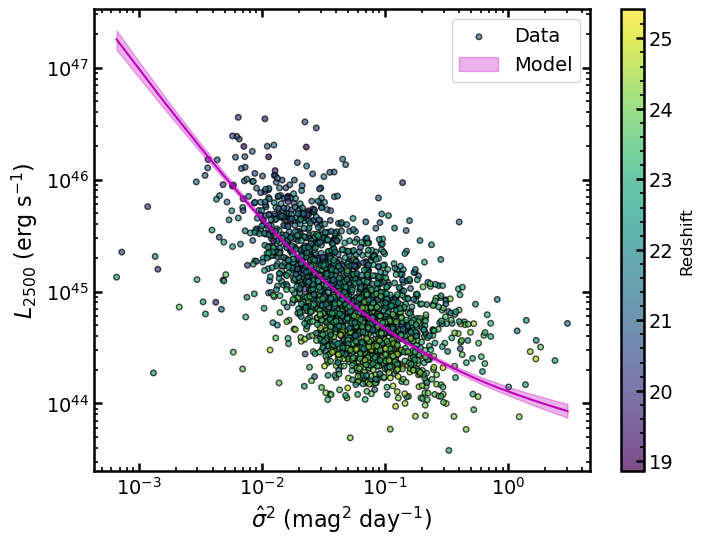

In [275]:
from hubble_plotting import plot_predicted_L2500_vs_sigmahat

plot_predicted_L2500_vs_sigmahat(flat_samples, df_agn, cosmo_model, show=True)

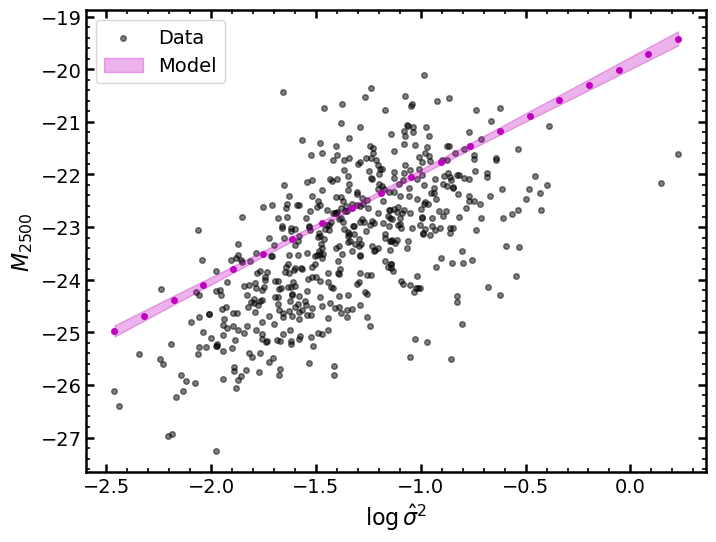

In [228]:
from hubble_plotting import plot_predicted_M2500_vs_sigmahat
plot_predicted_M2500_vs_sigmahat(flat_samples, df_agn, cosmo_model, show=True)

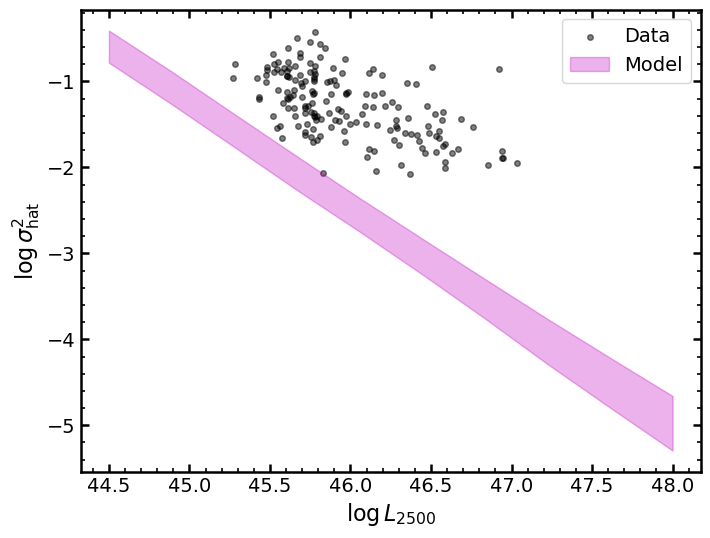

In [231]:
from scipy.optimize import basinhopping
from functools import partial

df = df_agn.copy()
df = df[
    (df['LOGL2500'] > 0) &
    (df['z'].between(1.2, 1.7))
    ]

def invert_log_sigma_hat_basin(target_log_l2500, sample_params, log_tau_UV_RF):
    def objective(log_sigma_hat):
        predicted_M2500 = M_model_agn(
            sample_params['M0_agn'],
            sample_params['log_sigma_hat_sq_break'],
            sample_params['eta_A1'], sample_params['eta_A2'],
            sample_params['eta_break'], sample_params['beta'],
            log_sigma_hat, log_tau_UV_RF
        )
        predicted_log_l2500 = (predicted_M2500-90) / (-2.5)
        return (predicted_log_l2500 - target_log_l2500) ** 2  # Minimize squared error

    minimizer_kwargs = {"method": "L-BFGS-B", "bounds": [(-3, 2)]}
    result = basinhopping(objective, x0=0.0, minimizer_kwargs=minimizer_kwargs, niter=10, seed=42)

    if result.lowest_optimization_result.success:
        return result.x[0]
    else:
        return np.nan

priors, model_labels, model_labels_latex = get_model_params(cosmo_model)
param_indices = {name: model_labels.index(name) for name in model_labels}

#log_l2500_grid = np.linspace(df['LOGL2500'].min(), df['LOGL2500'].max(), 10)
log_l2500_grid = np.linspace(44.5, 48, 10)
#log_lbol_grid = np.array([44, 45, 46, 47])
inverted_log_sigma_hat_samples = []


def invert_log_sigma_hat_basin_worker(arg):
    s, log_l, log_tau_UV_RF = arg
    sample_params = {
        'M0_agn': -25.5, #s[param_indices['M0_agn']],
        'log_sigma_hat_sq_break': s[param_indices['log_sigma_hat_sq_break']],
        'eta_A1': 4, #s[param_indices['eta_A1_agn']],
        'eta_A2': s[param_indices['eta_A2_agn']],
        'eta_break': s[param_indices['eta_break_agn']],
        'beta': -3, #s[param_indices['beta_agn']],
        'M0_agn': s[param_indices['M0_agn']],
        'eta_A1': s[param_indices['eta_A1_agn']],
        'beta': s[param_indices['beta_agn']],

    }

    log_sigma_hat = invert_log_sigma_hat_basin(log_l, sample_params, log_tau_UV_RF)
    return log_sigma_hat

from multiprocessing import Pool, cpu_count
n_processes = cpu_count() - 1

with Pool(processes=n_processes) as pool:
    arg_list = []
    for log_l in log_l2500_grid:
        for s in flat_samples[:10]:
            for i, d in df.sample(20, random_state=42).iterrows():
                arg_list.append((s, log_l, d['log_tau_UV_RF']))

    inverted_log_sigma_hat_samples = pool.map(invert_log_sigma_hat_basin_worker, arg_list)

# Convert to numpy array and reshape to (n_samples, len(log_lbol_grid))
inverted_log_sigma_hat_samples = np.array(inverted_log_sigma_hat_samples)
inverted_log_sigma_hat_samples = inverted_log_sigma_hat_samples.reshape(len(log_l2500_grid), -1)

log_sigma_hat_sq_samples = 2 * inverted_log_sigma_hat_samples

# Take percentiles in log space
log_sigma_hat_sq_median = np.nanmedian(log_sigma_hat_sq_samples, axis=1)
log_sigma_hat_sq_low = np.nanpercentile(log_sigma_hat_sq_samples, 16, axis=1)
log_sigma_hat_sq_high = np.nanpercentile(log_sigma_hat_sq_samples, 84, axis=1)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(df['log_lbol'], (2*df['log_sigma_hat_UV']), label='Data', color='k', alpha=0.5)
plt.fill_between(log_l2500_grid, log_sigma_hat_sq_low, log_sigma_hat_sq_high, color='m', alpha=0.3, label='Model')
#plt.scatter(log_l2500_grid, log_sigma_hat_sq_median, color='m')
plt.xlabel(r'$\log L_{\rm 2500}$')
plt.ylabel(r'$\log \sigma_{\rm hat}^2$')
plt.legend()
plt.show()

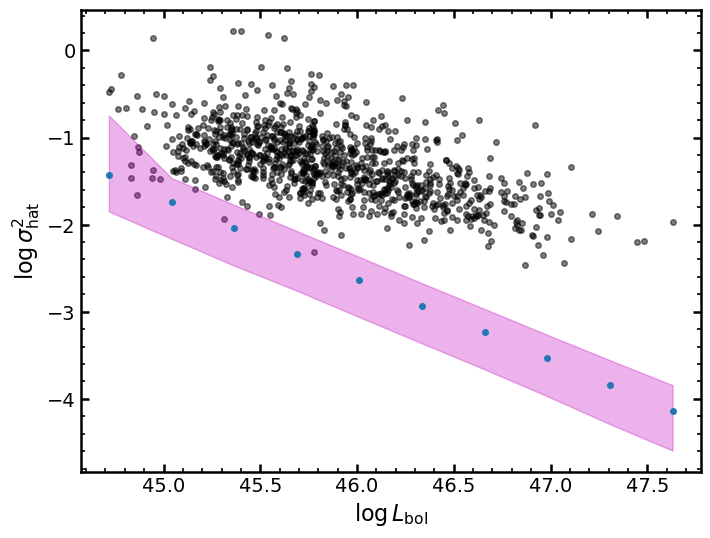

In [ ]:
from scipy.optimize import basinhopping
from functools import partial

def invert_log_sigma_hat_basin(target_log_lbol, sample_params, log_tau_UV_RF, alpha_nu, z):
    def objective(log_sigma_hat):
        predicted_M2500 = M_model_agn(
            sample_params['M0_agn'],
            sample_params['log_sigma_hat_sq_break'],
            sample_params['eta_A1'], sample_params['eta_A2'],
            sample_params['eta_break'], sample_params['beta'],
            log_sigma_hat, log_tau_UV_RF
        )
        predicted_Mi = calc_Mi_from_M2500(predicted_M2500, alpha_nu, z)
        #M_2500_actual = -2.5 * d['LOGL2500'] + 90
        predicted_log_lbol = (predicted_Mi-90) / (-2.5)
        return (predicted_log_lbol - target_log_lbol) ** 2  # Minimize squared error

    minimizer_kwargs = {"method": "L-BFGS-B", "bounds": [(-3, 2)]}
    result = basinhopping(objective, x0=0.0, minimizer_kwargs=minimizer_kwargs, niter=10, seed=42)

    if result.lowest_optimization_result.success:
        return result.x[0]
    else:
        return np.nan

priors, model_labels, model_labels_latex = get_model_params(cosmo_model)
param_indices = {name: model_labels.index(name) for name in model_labels}

log_lbol_grid = np.linspace(df_agn['log_lbol'].min(), df_agn['log_lbol'].max(), 10)
#log_lbol_grid = np.array([44, 45, 46, 47])
inverted_log_sigma_hat_samples = []


def invert_log_sigma_hat_basin_worker(arg):
    s, log_l, log_tau_UV_RF, alpha_nu, z = arg
    sample_params = {
        'M0_agn': s[param_indices['M0_agn']],
        'log_sigma_hat_sq_break': s[param_indices['log_sigma_hat_sq_break']],
        'eta_A1': s[param_indices['eta_A1_agn']],
        'eta_A2': s[param_indices['eta_A2_agn']],
        'eta_break': s[param_indices['eta_break_agn']],
        'beta': s[param_indices['beta_agn']],
    }

    log_sigma_hat = invert_log_sigma_hat_basin(log_l, sample_params, log_tau_UV_RF, alpha_nu, z)
    return log_sigma_hat

from multiprocessing import Pool, cpu_count
n_processes = cpu_count() - 1

with Pool(processes=n_processes) as pool:
    arg_list = []
    for log_l in log_lbol_grid:
        for s in flat_samples[:50]:
            for i, d in df_agn.sample(10, random_state=42).iterrows():
                arg_list.append((s, log_l, d['log_tau_UV_RF'], d['alpha_nu'], d['z']))

    inverted_log_sigma_hat_samples = pool.map(invert_log_sigma_hat_basin_worker, arg_list)

# Convert to numpy array and reshape to (n_samples, len(log_lbol_grid))
inverted_log_sigma_hat_samples = np.array(inverted_log_sigma_hat_samples)
inverted_log_sigma_hat_samples = inverted_log_sigma_hat_samples.reshape(len(log_lbol_grid), -1)

log_sigma_hat_sq_samples = 2 * inverted_log_sigma_hat_samples

# Take percentiles in log space
log_sigma_hat_sq_median = np.nanmedian(log_sigma_hat_sq_samples, axis=1)
log_sigma_hat_sq_low = np.nanpercentile(log_sigma_hat_sq_samples, 16, axis=1)
log_sigma_hat_sq_high = np.nanpercentile(log_sigma_hat_sq_samples, 84, axis=1)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(df_agn['log_lbol'], (2*df_agn['log_sigma_hat_UV']), label='Data', color='k', alpha=0.5)
plt.fill_between(log_lbol_grid, log_sigma_hat_sq_low, log_sigma_hat_sq_high, color='m', alpha=0.3, label='Best fit model (1σ band)')
plt.scatter(log_lbol_grid, log_sigma_hat_sq_median)
plt.xlabel(r'$\log L_{\rm bol}$')
plt.ylabel(r'$\log \sigma_{\rm hat}^2$')
plt.show()

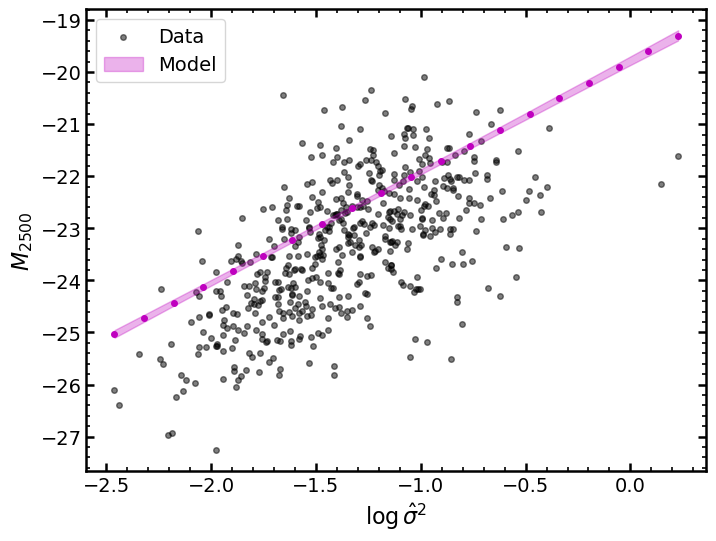

In [198]:
from hubble_plotting import plot_predicted_M2500_vs_sigmahat
plot_predicted_M2500_vs_sigmahat(flat_samples, df_agn, cosmo_model, show=True)

Fitted parameters:
  x_break: -1.2456
  d1: 3.0082
  d2: 0.5280
  M0: -22.4895
  ds: 14.5118


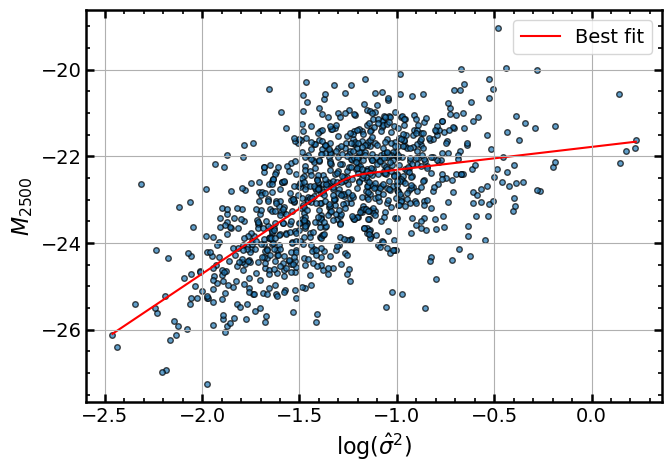

In [159]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt


def broken_power_law(x, x_break, d1, d2, M0, ds):
    """Broken power law defined to be zero at x_break.
    That decorrelates d1, d2 from M0_agn.
    """
    #print(f"broken_power_law: x={x}, x_break={x_break}, d1={d1}, d2={d2}, ds={ds}")
    delta = x - x_break
    term = (d2 - d1) / ds * np.log10(1 + 10**(ds * delta))
    offset = (d2 - d1) / ds * np.log10(2)  # value of the term when delta = 0
    return d1 * delta + term - offset + M0

d = df_agn[df_agn['LOGL2500'] > 0]  # Filter to only include objects with LOGL2500 < 0
initial_guess = [-1.1, 4, 0, -27, 2]
M_2500_actual = -2.5 * d['LOGL2500'] + 90

params, cov = curve_fit(
    broken_power_law,
    2*d['log_sigma_hat_UV'],
    M_2500_actual,
    p0=initial_guess,
    bounds=([-1.5, 3, -1, -30, 0], [-0.8, 6, 2, -20, 100])
)

print("Fitted parameters:")
for name, value in zip(['x_break', 'd1', 'd2', 'M0', 'ds'], params):
    print(f"  {name}: {value:.4f}")

x_fit = np.linspace((2*d['log_sigma_hat_UV']).min(), (2*d['log_sigma_hat_UV']).max(), 200)
y_fit = broken_power_law(x_fit, *params)

plt.figure(figsize=(7, 5))
plt.scatter(2*d['log_sigma_hat_UV'], M_2500_actual, alpha=0.7, edgecolor='k', zorder=-2)
plt.plot(x_fit, y_fit, color='red', label='Best fit', zorder=-1)

plt.legend()
plt.xlabel(r'$\log(\hat{\sigma}^2)$')
plt.ylabel(r'$M_{2500}$')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def plot_predicted_sigma_hat_vs_luminosity_pl(samples, df_agn, cosmo_model, show=False):
    priors, model_labels, model_labels_latex = get_model_params(cosmo_model)
    param_indices = {name: model_labels.index(name) for name in model_labels}

    log_lbol = df_agn['log_lbol'].values
    log_sigma_hat_sq = 2 * df_agn['log_sigma_hat_UV'].values
    sigma_hat_sq = 10 ** log_sigma_hat_sq
    sigma_hat_sq_err = np.log(10) * sigma_hat_sq * 2 * df_agn['log_sigma_hat_UV_err']
    lbol = 10 ** log_lbol
    lbol_err = np.log(10) * lbol * df_agn['log_lbol_err']

    # Step 1: Define log_sigma_hat grid
    log_sigma_hat_linspace = np.linspace(
        df_agn['log_sigma_hat_UV'].min(), df_agn['log_sigma_hat_UV'].max(), 100
    )
    log_sigma_hat_sq_linspace = 2 * log_sigma_hat_linspace
    sigma_hat_sq_linspace = 10 ** log_sigma_hat_sq_linspace  # y-axis

    # Step 2: Predict L_bol for each sample
    predicted_log_lbol_samples = []

    for s in tqdm(samples, total=len(samples), desc="Processing samples"):
        log_tau_UV_RF = df_agn['log_tau_UV_RF'].mean()
        alpha_nu = df_agn['alpha_nu'].mean()
        z = 2

        predicted_M_2500_sample = M_model_agn(
            s[param_indices['M0_sn']] + s[param_indices['delta_M0_agn']],
            s[param_indices['log_sigma_hat_sq_break']],
            s[param_indices['eta_A1_agn']], s[param_indices['eta_A2_agn']],
            s[param_indices['eta_break_agn']],
            s[param_indices['beta_agn']],
            log_sigma_hat_linspace, log_tau_UV_RF
        )

        #predicted_M_i_sample = convert_M2500_to_MI(predicted_M_2500_sample, alpha_nu) - 2


        predicted_log_lbol_sample = (90 - predicted_M_2500_sample) / 2.5
        predicted_log_lbol_samples.append(predicted_log_lbol_sample)

    

    # Step 3: Compute percentiles of predicted L_bol
    predicted_log_lbol_samples = np.array(predicted_log_lbol_samples)  # shape: (n_samples, 100)
    lbol_median = 10 ** np.median(predicted_log_lbol_samples, axis=0)
    lbol_low = 10 ** np.percentile(predicted_log_lbol_samples, 16, axis=0)
    lbol_high = 10 ** np.percentile(predicted_log_lbol_samples, 84, axis=0)

    # Step 4: Plotting
    plt.figure(figsize=(8, 6))

    # Predictive band (x = L_bol, y = sigma_hat^2)
    plt.fill_betweenx(
        sigma_hat_sq_linspace,
        lbol_low, lbol_high,
        color='m', alpha=0.3, label='Best fit model (1σ band)'
    )
    plt.plot(lbol_median, sigma_hat_sq_linspace, color='m', lw=2)

    # Observed data
    log_lbol = df_agn['log_lbol'].values
    log_sigma_hat_sq = 2 * df_agn['log_sigma_hat_UV'].values
    sigma_hat_sq = 10 ** log_sigma_hat_sq
    lbol = 10 ** log_lbol
    sigma_hat_sq_err = np.log(10) * sigma_hat_sq * 2 * df_agn['log_sigma_hat_UV_err']
    lbol_err = np.log(10) * lbol * df_agn['log_lbol_err']

    plt.errorbar(
        lbol,
        sigma_hat_sq,
        xerr=lbol_err,
        yerr=sigma_hat_sq_err,
        fmt='o', linestyle='none', color='k', alpha=0.2, markersize=4, lw=1, label='AGN'
    )

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'$L_{\mathrm{bol}}$ (erg/s)')
    plt.ylabel(r'$\hat{\sigma}^2_\mathrm{UV}$ (mag$^2$ day$^{-1}$)')
    plt.title(r'$\hat{\sigma}^2$ vs. $L_{\mathrm{bol}}$')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if show:
        plt.show()
    plt.close()


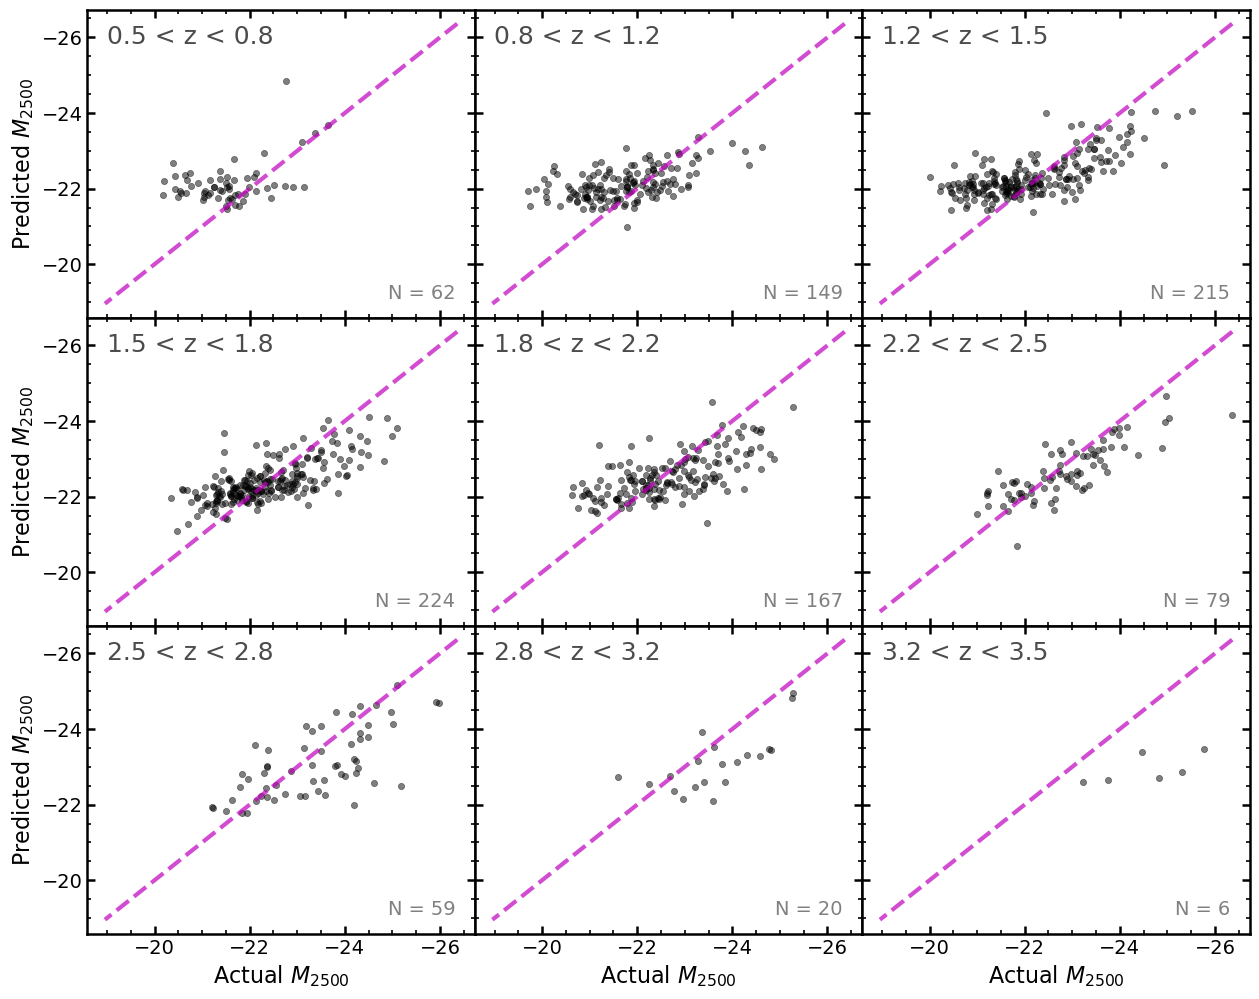

In [185]:
from hubble_plotting import plot_predicted_vs_actual_M2500

plot_predicted_vs_actual_M2500(flat_samples, df_agn, cosmo_model, show=True)

In [4]:
df_agn = load_quasar_data("data/july19_goodsources_chisq5and10_mean1_N20w4000s500_merged.h5", populate_sdss=False, apply_cut=False)

objs = read_quasars_from_hdf5("data/july19_goodsources_chisq5and10_mean1_N20w4000s500_merged.h5")

Reading quasars from HDF5: 100%|██████████| 657/657 [00:01<00:00, 421.97it/s]


Number of quasars loaded: 657
   object_id    chi_sq       ebv         z  EXTINCTION        M_i
0    1384141  6.294867  0.302981  0.329846    1.075510 -22.982048
1    1384142  8.473950  0.301818  2.445898    1.071410 -28.372445
2    1384143  8.662985  0.273010  1.838447    0.969115 -26.271487
3    1384144  4.035444  0.248959  1.885438    0.883784 -26.304172
4    1384145  4.061303  0.167054  2.740166    0.592995 -26.666071
Columns with NaNs: ['chi_sq', 'f_host_4200', 'apparent_mag_2500']
Before dropping NaNs and infs, number of quasars: 657
Number of quasars with 0 < z <= 0.5: 19
Number of quasars with z > 3: 11
Skipping data cuts as apply_cut is False.


Reading quasars from HDF5: 100%|██████████| 657/657 [00:01<00:00, 418.47it/s]


In [15]:
df_agn[df_agn['object_id'] == '1426715']

,object_id,EXTINCTION,FHOST_5100,LOGL1350,LOGL1350_ERR,LOGL1700,LOGL1700_ERR,LOGL2500,LOGL2500_ERR,LOGL3000,...,z,bestP,chi_sq,alpha_nu,alpha_nu_err,MY_LOGL2500,MY_LOGL2500_ERR,f_host_4200,apparent_mag_2500,apparent_mag_2500_err
313,1426715,0.043967,0.0,0.0,-1.0,0.0,-1.0,44.705462,0.00707,44.660663,...,0.747258,"{'eta_A1': -0.37517332094112543, 'eta_A2': -0....",82.674007,-0.5,0.1,44.701844,0.004512,-1.0,21.677401,0.1


In [ ]:
objs[0]

In [14]:
obj = list(filter(lambda x: x['object_id'] == '1426715', objs))
obj

[{'object_id': '1426715',
  'EXTINCTION': np.float32(0.04396659),
  'FHOST_5100': np.float64(0.0),
  'LOGL1350': np.float64(0.0),
  'LOGL1350_ERR': np.float64(-1.0),
  'LOGL1700': np.float64(0.0),
  'LOGL1700_ERR': np.float64(-1.0),
  'LOGL2500': np.float64(44.705461981300076),
  'LOGL2500_ERR': np.float64(0.007070080578159831),
  'LOGL3000': np.float64(44.660662916933866),
  'LOGL3000_ERR': np.float64(0.0065354910600987),
  'LOGL5100': np.float64(44.54086783574608),
  'LOGL5100_ERR': np.float64(0.0132386690745427),
  'M_i': np.float64(-22.931088735029757),
  'X': array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          8.03996350e+03, 8.04198403e+03, 8.04588137e+03],
         [0.00000000e+00, 3.00000000e+00, 2.00000000e+00, ...,
          2.00000000e+00, 2.00000000e+00, 2.00000000e+00]], shape=(2, 597)),
  'apparent_mag_g': np.float32(20.817877),
  'apparent_mag_g_err': np.float64(0.031921253364252736),
  'apparent_mag_i': np.float32(20.741247),
  'apparent_mag_i_err': n